# Exploratory Data Analysis (EDA)

## Objetivo

Explorar el conjunto de movimientos del centro de distribución de Puebla y crear visualizaciones interactivas para apoyar decisiones logísticas. El archivo CSV está un nivel arriba de esta carpeta, en la raíz del proyecto.

> El conjunto es didáctico. Las temperaturas se usan solo como variables ilustrativas; esta primera exploración se enfoca en entradas, salidas, mermas, existencias y destinos.

### Kernel de Python

Al abrir el notebook, selecciona el kernel **Python 3.14.7 (base) de Miniconda**, donde se comprobó que están disponibles pandas y Plotly. Después, ejecuta las celdas en orden.

In [1]:
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

csv_path = Path("..") / "aguacate_hass_agosto_septiembre_ejercicio.csv"
df = pd.read_csv(csv_path)
df["fecha"] = pd.to_datetime(df["fecha"], format="%d/%m/%Y")

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.head())
print("\nTipos de movimiento:")
print(df["tipo_movimiento"].value_counts())
print("\nValores ausentes por columna:")
print(df.isna().sum())

Filas: 245 | Columnas: 22


,fecha,id_movimiento,lote_id,tipo_movimiento,origen,centro_distribucion,destino,entradas_kg,salidas_kg,mermas_kg,...,temperatura_origen_c,temperatura_cd_puebla_c,temperatura_destino_c,humedad_cd_pct,transito_dias,vida_util_estimada_dias,nivel_riesgo,observacion,accion_sugerida,fuente_dato
0,2026-08-01,MOV-0001,HASS-0801,Entrada,Veracruz,Puebla,Centro de distribucion Puebla,1668,0,0,...,30.6,31.9,30.3,69,1,5,Alto,Recepcion procedente de Veracruz; inspeccionar...,"Priorizar inspeccion del lote, despacho y revi...",Escenario didactico; temperaturas ilustrativas...
1,2026-08-01,MOV-0002,HASS-0801,Salida,Veracruz,Puebla,Ciudad de Mexico,0,466,0,...,30.6,31.9,30.3,69,1,5,Alto,Despacho desde Puebla hacia Ciudad de Mexico. ...,"Priorizar inspeccion del lote, despacho y revi...",Escenario didactico; temperaturas ilustrativas...
2,2026-08-01,MOV-0003,HASS-0801,Salida,Veracruz,Puebla,Guadalajara,0,445,0,...,30.6,31.9,30.3,69,1,5,Alto,Despacho desde Puebla hacia Guadalajara. Expos...,"Priorizar inspeccion del lote, despacho y revi...",Escenario didactico; temperaturas ilustrativas...
3,2026-08-01,MOV-0004,HASS-0801,Salida,Veracruz,Puebla,Monterrey,0,430,0,...,30.6,31.9,30.3,69,1,5,Alto,Despacho desde Puebla hacia Monterrey. Exposic...,"Priorizar inspeccion del lote, despacho y revi...",Escenario didactico; temperaturas ilustrativas...
4,2026-08-01,MOV-0005,HASS-0801,Merma,Veracruz,Puebla,Centro de distribucion Puebla,0,0,46,...,30.6,31.9,30.3,69,1,5,Alto,"Baja por dano, deterioro o vida util; document...","Priorizar inspeccion del lote, despacho y revi...",Escenario didactico; temperaturas ilustrativas...



Tipos de movimiento:
tipo_movimiento
Salida     147
Entrada     49
Merma       49
Name: count, dtype: int64

Valores ausentes por columna:
fecha                       0
id_movimiento               0
lote_id                     0
tipo_movimiento             0
origen                      0
centro_distribucion         0
destino                     0
entradas_kg                 0
salidas_kg                  0
mermas_kg                   0
existencia_inicial_cd_kg    0
existencia_actual_cd_kg     0
temperatura_origen_c        0
temperatura_cd_puebla_c     0
temperatura_destino_c       0
humedad_cd_pct              0
transito_dias               0
vida_util_estimada_dias     0
nivel_riesgo                0
observacion                 0
accion_sugerida             0
fuente_dato                 0
dtype: int64


In [2]:
ledger = df.sort_values("id_movimiento").reset_index(drop=True)

expected_stock = (
    ledger["existencia_inicial_cd_kg"]
    + ledger["entradas_kg"]
    - ledger["salidas_kg"]
    - ledger["mermas_kg"]
)
balance_is_valid = expected_stock.eq(ledger["existencia_actual_cd_kg"])
previous_stock = ledger["existencia_actual_cd_kg"].iloc[:-1].reset_index(drop=True)
next_opening_stock = ledger["existencia_inicial_cd_kg"].iloc[1:].reset_index(drop=True)
stock_is_continuous = previous_stock.eq(next_opening_stock)

opening_stock = int(ledger.iloc[0]["existencia_inicial_cd_kg"])
closing_stock = int(ledger.iloc[-1]["existencia_actual_cd_kg"])
calculated_closing_stock = int(
    opening_stock
    + ledger["entradas_kg"].sum()
    - ledger["salidas_kg"].sum()
    - ledger["mermas_kg"].sum()
)

assert ledger["id_movimiento"].is_unique, "Hay identificadores de movimiento repetidos."
assert balance_is_valid.all(), "Uno o más movimientos no concilian."
assert stock_is_continuous.all(), "Hay una ruptura entre saldos consecutivos."
assert closing_stock == calculated_closing_stock, "No coincide el balance agregado."

print(f"Movimientos únicos: {len(ledger)}")
print(f"Balance por movimiento conciliado: {balance_is_valid.sum()} / {len(ledger)}")
print(f"Continuidad de existencias conciliada: {stock_is_continuous.sum()} / {len(stock_is_continuous)}")
print(f"Existencia final conciliada: {closing_stock:,} kg")

Movimientos únicos: 245
Balance por movimiento conciliado: 245 / 245
Continuidad de existencias conciliada: 244 / 244
Existencia final conciliada: 11,752 kg


## El recorrido de cada kilogramo

El diagrama Sankey integra el balance del periodo: existencia inicial y recepciones entran al centro de Puebla; de ahí se distribuyen los despachos por ciudad, las mermas registradas y la existencia final. Así se puede revisar de un vistazo que los flujos cierren.

In [3]:
destination_totals = (
    df.loc[df["tipo_movimiento"] == "Salida"]
    .groupby("destino")["salidas_kg"]
    .sum()
)

flow_labels = [
    "Existencia inicial",
    "Recepciones desde Veracruz",
    "Centro de distribución · Puebla",
    "Ciudad de México",
    "Guadalajara",
    "Monterrey",
    "Mermas registradas",
    "Existencia final",
]
flow_values = [
    opening_stock,
    int(df["entradas_kg"].sum()),
    int(destination_totals["Ciudad de Mexico"]),
    int(destination_totals["Guadalajara"]),
    int(destination_totals["Monterrey"]),
    int(df["mermas_kg"].sum()),
    closing_stock,
]

assert sum(flow_values[:2]) == sum(flow_values[2:])

fig_flow = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node={
                "pad": 22,
                "thickness": 18,
                "line": {"color": "white", "width": 1},
                "label": flow_labels,
                "color": [
                    "#79a88b",
                    "#2a9d8f",
                    "#457b9d",
                    "#e9a23b",
                    "#df7b43",
                    "#c85c5c",
                    "#9b6a68",
                    "#6a9c78",
                ],
            },
            link={
                "source": [0, 1, 2, 2, 2, 2, 2],
                "target": [2, 2, 3, 4, 5, 6, 7],
                "value": flow_values,
            },
        )
    ]
)
fig_flow.update_layout(
    title="Balance de aguacate Hass · Veracruz → Puebla → destinos",
    height=520,
    font={"size": 13},
)
fig_flow.show()

## Tres vistas para decisiones operativas

Después de revisar el balance integral, estas visualizaciones responden preguntas distintas: ¿cómo evoluciona la existencia en Puebla?, ¿qué tamaños de despacho son frecuentes? y ¿cómo se comparan las entradas y salidas de cada día? Se priorizan estas vistas para mantener el análisis breve y útil para el siguiente paso: construir una aplicación.

### Evolución de las existencias

Se toma el último saldo registrado de cada fecha para observar el cierre diario del inventario en Puebla.

In [4]:
daily_stock = (
    df.sort_values(["fecha", "id_movimiento"])
    .groupby("fecha", as_index=False)
    .tail(1)[["fecha", "existencia_actual_cd_kg"]]
    .sort_values("fecha")
)

fig_stock = px.line(
    daily_stock,
    x="fecha",
    y="existencia_actual_cd_kg",
    markers=True,
    title="Existencia al cierre de cada día en Puebla",
    labels={"fecha": "Fecha", "existencia_actual_cd_kg": "Existencia (kg)"},
)
fig_stock.show()
daily_stock.tail()

,fecha,existencia_actual_cd_kg
224,2026-09-22,10749
229,2026-09-23,11223
234,2026-09-24,11591
239,2026-09-25,11548
244,2026-09-26,11752


## Histograma del tamaño de los despachos

El histograma muestra cuántos despachos se realizaron en cada rango de kilogramos. Se consideran solo movimientos de salida, excluyendo los registros con cantidad cero.

In [5]:
dispatch_data = df.loc[df["tipo_movimiento"] == "Salida", "salidas_kg"]

fig_dispatch_histogram = go.Figure(
    data=[
        go.Histogram(
            x=dispatch_data,
            nbinsx=12,
            marker_color="#1f77b4",
            name="Despachos",
        )
    ]
)
fig_dispatch_histogram.update_layout(
    title="Distribución del volumen por despacho",
    xaxis_title="Kilogramos por despacho",
    yaxis_title="Número de despachos",
    bargap=0.08,
)
fig_dispatch_histogram.show()

## Gráfico de dispersión: entradas y salidas diarias

Cada punto representa un día de operación. La línea diagonal de referencia muestra igualdad entre entradas y salidas; los puntos arriba o abajo ayudan a detectar días donde los despachos superaron o no las recepciones. La existencia acumulada del centro también influye, así que esta comparación no sustituye el balance de inventario.

In [6]:
daily_inbound_outbound = df.groupby("fecha", as_index=False)[
    ["entradas_kg", "salidas_kg"]
].sum()

fig_inbound_outbound = go.Figure(
    data=[
        go.Scatter(
            x=daily_inbound_outbound["entradas_kg"],
            y=daily_inbound_outbound["salidas_kg"],
            mode="markers",
            text=daily_inbound_outbound["fecha"].dt.strftime("%d/%m/%Y"),
            marker={"size": 10, "color": "#e07a35", "opacity": 0.8},
            hovertemplate=(
                "Fecha: %{text}<br>"
                "Entradas: %{x:,} kg<br>"
                "Salidas: %{y:,} kg<extra></extra>"
            ),
        )
    ]
)

axis_min = 0
axis_max = max(
    daily_inbound_outbound["entradas_kg"].max(),
    daily_inbound_outbound["salidas_kg"].max(),
)
fig_inbound_outbound.add_shape(
    type="line",
    x0=axis_min,
    y0=axis_min,
    x1=axis_max,
    y1=axis_max,
    line={"color": "gray", "dash": "dash"},
)
fig_inbound_outbound.update_layout(
    title="Entradas y salidas diarias del centro de distribución",
    xaxis_title="Entradas diarias (kg)",
    yaxis_title="Salidas diarias (kg)",
)
fig_inbound_outbound.show()

## De los gráficos a las decisiones

Las cuatro vistas se complementan y siguen el recorrido del inventario:

- **Sankey:** concilia existencia inicial y recepciones con los despachos a cada ciudad, las mermas y la existencia final. Ayuda a ubicar cómo se distribuyó el volumen total.
- **Histograma:** muestra los tamaños de despacho más frecuentes y su variabilidad; puede orientar la planeación de preparación y transporte.
- **Dispersograma:** identifica días en que las salidas superaron las entradas. Antes de cambiar la programación, se revisan la existencia disponible y los pedidos pendientes.
- **Línea de existencias:** muestra la tendencia del inventario en Puebla. Una alerta de reabastecimiento requeriría políticas reales de inventario mínimo, tiempos de reposición y demanda esperada; aquí no se inventan umbrales.

Este análisis muestra cómo pasar de revisar la calidad de los datos a formular preguntas de gestión. El conjunto es didáctico, por lo que sus resultados sirven para practicar y diseñar la aplicación, no para dirigir una operación real.

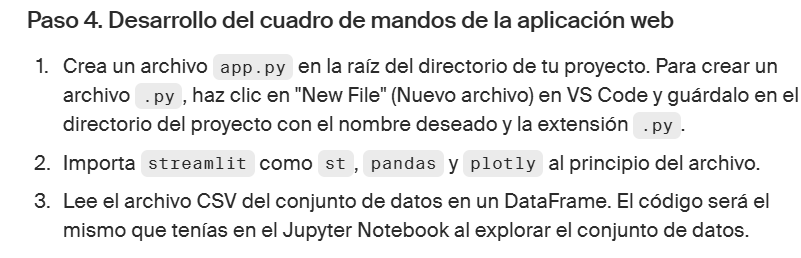